In [3]:
#competitions
competitions = sb.competitions()

#matches
matches = sb.matches(competition_id=43, season_id=3)

#Choosing any random match
match_id = matches.iloc[0].match_id

#Events from that match
sb_df = sb.events(match_id=match_id)

In [4]:
#Printing all column names
print(sb_df.columns.tolist())
#Number of columns
print("Number of columns:", sb_df.shape[1])

['50_50', 'bad_behaviour_card', 'ball_receipt_outcome', 'ball_recovery_recovery_failure', 'block_deflection', 'block_offensive', 'carry_end_location', 'clearance_aerial_won', 'counterpress', 'dribble_nutmeg', 'dribble_outcome', 'duel_outcome', 'duel_type', 'duration', 'foul_committed_advantage', 'foul_committed_card', 'foul_committed_penalty', 'foul_committed_type', 'foul_won_advantage', 'foul_won_defensive', 'foul_won_penalty', 'goalkeeper_body_part', 'goalkeeper_end_location', 'goalkeeper_outcome', 'goalkeeper_position', 'goalkeeper_technique', 'goalkeeper_type', 'id', 'index', 'interception_outcome', 'location', 'match_id', 'minute', 'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id', 'pass_backheel', 'pass_body_part', 'pass_cross', 'pass_deflected', 'pass_end_location', 'pass_goal_assist', 'pass_height', 'pass_length', 'pass_outcome', 'pass_recipient', 'pass_recipient_id', 'pass_shot_assist', 'pass_switch', 'pass_type', 'period', 'play_pattern', 'player', 'player_id', 'positi

In [5]:
#Dataset example
sb_df.tail(5)

,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,counterpress,dribble_nutmeg,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
4014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Tactical,103.0,Marcus Rashford,3318.0,NaN,England,768,00:07:33.493,Substitution,NaN
4015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Tactical,103.0,Cristian Eduardo Zapata Valencia,6360.0,NaN,Colombia,769,00:10:17.880,Substitution,NaN
4016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 442, 'lineup': [{'player': {'id'...",Colombia,769,00:16:06.374,Tactical Shift,NaN
4017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Colombia,769,00:31:38.320,Camera off,NaN
4018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,England,768,00:41:49.320,Camera off,NaN


In [6]:
#Number of seperate competitions
num_competitions = competitions.shape[0]
print("Number of competitions:", num_competitions)

#Number of Seasons
num_seasons = competitions['season_id'].nunique()
print("Number of seasons:", num_seasons)

Number of competitions: 75
Number of seasons: 48


### We will only consider la liga seasons to make the dataset smaller and easier to handle

### Load match info dataset

In [9]:
all_matches = []

for file_path in MATCHES_DIR.glob("*.json"):
    with file_path.open("r", encoding="utf-8") as f:
        data = json.load(f)
        if isinstance(data, list) and len(data) > 0:
            for match in data:
                match_flat = {
                    'match_id': match['match_id'],
                    'match_date': match['match_date'],
                    'home_team_name': match['home_team']['home_team_name'],
                    'away_team_name': match['away_team']['away_team_name'],
                    'competition_name': match['competition']['competition_name'],
                    'season_name': match['season']['season_name'],
                    'home_score': match.get('home_score'),
                    'away_score': match.get('away_score')
                }
                all_matches.append(match_flat)
        else:
            print(f"Empty or unexpected JSON: {file_path}")

matches_df = pd.DataFrame(all_matches)


### Now, we load per match event data

In [ ]:
all_events = []

# Iterate over matches with both id/date and official final score.
for _, row in matches_df.iterrows():
    match_id = row['match_id']
    match_date = row['match_date']
    home_team = row['home_team_name']
    away_team = row['away_team_name']
    official_home_score = row['home_score']
    official_away_score = row['away_score']

    event_file = EVENTS_DIR / f"{match_id}.json"

    if not event_file.exists():
        print(f"Missing events file for match {match_id}")
        continue

    with event_file.open("r", encoding="utf-8") as f:
        events = json.load(f)
        if not events:
            continue
        df = pd.json_normalize(events)
        df['match_id'] = match_id
        df['match_date'] = match_date
        df['home_team'] = home_team
        df['away_team'] = away_team
        df['official_home_score'] = official_home_score
        df['official_away_score'] = official_away_score
        all_events.append(df)

if all_events:
    la_liga_events_df = pd.concat(all_events, ignore_index=True)
    print("Total La Liga events:", len(la_liga_events_df))
    print("Columns:", la_liga_events_df.columns[:10])
else:
    print("No events found at all")


### EDA

In [ ]:
print("Total La Liga matches:", len(matches_df))
print(matches_df.head())

In [ ]:
la_liga_events_df.head(5)

In [ ]:
print(list(la_liga_events_df.columns))

In [ ]:
shots_df = la_liga_events_df[la_liga_events_df['type.name'] == 'Shot'].copy()
shots_df = shots_df.dropna(subset=['location'])

shots_df['x'] = shots_df['location'].apply(lambda loc: loc[0] if isinstance(loc, (list, tuple)) else np.nan)
shots_df['y'] = shots_df['location'].apply(lambda loc: loc[1] if isinstance(loc, (list, tuple)) else np.nan)

shots_df = shots_df.dropna(subset=['x', 'y'])

x_edges = np.array([0,18,35,60,85,102,114,120])
y_edges = np.array([0,18,30,50,62,80])

shots_df['x_bin'] = pd.cut(shots_df['x'], bins=x_edges, labels=False, include_lowest=True)
shots_df['y_bin'] = pd.cut(shots_df['y'], bins=y_edges, labels=False, include_lowest=True)

x_bin_range = np.arange(len(x_edges)-1)
y_bin_range = np.arange(len(y_edges)-1)

grid_shots = (
    shots_df.groupby(['y_bin','x_bin'])
    .size()
    .reindex(
        pd.MultiIndex.from_product(
            [y_bin_range,x_bin_range],
            names=['y_bin','x_bin']
        ),
        fill_value=0
    )
    .unstack(level=1)
)

shot_percent_grid = (grid_shots / grid_shots.values.sum()) * 100

from mplsoccer import Pitch
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='white',
    line_color='black',
    linewidth=1.4,
    line_zorder=5
)

fig, ax = pitch.draw(figsize=(8,5))

max_val = shot_percent_grid.values.max()

for yi in range(len(y_edges)-1):
    for xi in range(len(x_edges)-1):

        val = shot_percent_grid.iloc[yi, xi]

        x0 = x_edges[xi]
        x1 = x_edges[xi+1]
        y0 = y_edges[yi]
        y1 = y_edges[yi+1]

        alpha = 0.10 + (0.75 * (val / max_val)) if max_val > 0 else 0.1

        rect = plt.Rectangle(
            (x0,y0),
            x1-x0,
            y1-y0,
            facecolor='#5aa05a',
            edgecolor='black',
            linewidth=0.8,
            alpha=alpha,
            zorder=1
        )

        ax.add_patch(rect)

        ax.text(
            (x0+x1)/2,
            (y0+y1)/2,
            f"{val:.1f}",
            ha='center',
            va='center',
            fontsize=8,
            fontweight='bold',
            color='black',
            zorder=6
        )

plt.title('Shot Origin Map by Tactical Rectangle Zones (%)', fontsize=14, pad=14)
plt.tight_layout()
plt.show()

In [ ]:
# Loading Elo ratings CSV from repo-local raw data.
elo_df = pd.read_csv(ELO_PATH, encoding="latin1")
elo_df.head()

In [ ]:
# Filter Elo ratings to teams that appear in the loaded match metadata.
# This avoids fragile hardcoded team-name lists and handles accents consistently.
la_liga_teams = sorted(
    set(matches_df["home_team_name"].dropna()) |
    set(matches_df["away_team_name"].dropna())
)

elo_df_filtered = elo_df[elo_df["club"].isin(la_liga_teams)].copy()

missing_elo_teams = sorted(set(la_liga_teams) - set(elo_df_filtered["club"].unique()))
print("Teams in matches:", len(la_liga_teams))
print("Teams matched in Elo:", elo_df_filtered["club"].nunique())
print("Teams missing from Elo:", missing_elo_teams)

# Save generated/intermediate data under data/processed, not the repo root.
elo_df_filtered.to_csv(PROCESSED_DATA_DIR / "eloratings_laliga.csv", index=False)

elo_df_filtered.head()


### EDA

In [ ]:
# Top duplicate / frequent names
elo_df_filtered["club"].value_counts().head(20)

In [ ]:
# Elo distribution
fig, ax = plt.subplots(figsize=(8,5))

ax.hist(
    elo_df_filtered["elo"],
    bins=30,
    color="#3266ad",
    edgecolor="black",
    alpha=0.8
)

ax.set_title("Elo Rating Distribution", fontsize=14)
ax.set_xlabel("Elo Rating")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
top5_elo = (
    elo_df_filtered.groupby("club")["elo"]
    .max()
    .sort_values(ascending=False)
    .head(5)
)

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    top5_elo.index,
    top5_elo.values,
    color="#3266ad",
    width=0.6
)

for bar, val in zip(bars, top5_elo.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        f"{val:.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title("Top 5 Highest Elo Ratings Ever", fontsize=14)
ax.set_ylabel("Maximum Elo")
ax.set_xlabel("Club")
ax.grid(axis="y", alpha=0.25)
ax.set_ylim(0, top5_elo.max()*1.12)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# Sort by team and date to prepare for merge_asof
elo_df_filtered_sort = elo_df_filtered.sort_values(['club', 'date_of_elo'])
la_liga_events_df_sort = la_liga_events_df.sort_values('match_date')

In [ ]:
# Make sure indexes are default integers
la_liga_events_df_sort = la_liga_events_df_sort.reset_index(drop=True)

# Merge for home team
la_liga_events_df_sort = pd.merge_asof(
    la_liga_events_df_sort.sort_values('match_date'),
    elo_df_filtered_sort.rename(columns={'club': 'home_team', 'elo': 'home_elo'}).sort_values('date_of_elo'),
    left_on='match_date',
    right_on='date_of_elo',
    by='home_team',
    direction='backward'
)
la_liga_events_df_sort = la_liga_events_df_sort.drop(columns=['date_of_elo'])

# Merge for away team
la_liga_events_df_sort = pd.merge_asof(
    la_liga_events_df_sort.sort_values('match_date'),
    elo_df_filtered_sort.rename(columns={'club': 'away_team', 'elo': 'away_elo'}).sort_values('date_of_elo'),
    left_on='match_date',
    right_on='date_of_elo',
    by='away_team',
    direction='backward'
)
la_liga_events_df_sort = la_liga_events_df_sort.drop(columns=['date_of_elo'])


In [ ]:
print(la_liga_events_df_sort[['home_team', 'away_team', 'match_date', 'home_elo', 'away_elo']].tail())

In [ ]:
print(la_liga_events_df_sort.columns.tolist())
print("Number of columns:",la_liga_events_df_sort.shape[1])

### Creating sequential input–output pairs for model training

In [ ]:
X = []
y = []
timestep_mask = []

numeric_cols = [
    # Base game-state features from the paper
    'game_time_pct', 'goal_diff', 'time_remaining',

    # Team strength
    'home_elo_diff', 'is_home_possession',

    # Current scoring context
    'home_score', 'away_score',
    'home_xg_cumulative', 'away_xg_cumulative',

    # Possession behaviour features
    'possession_duration', 'events_count',
    'dribbles_count', 'dribbles_completed_pct',
    'carries_count', 'carries_total_length', 'carries_mean_length',
    'passes_count', 'passes_completed_pct',
    'passes_total_length', 'passes_mean_length',
    'shots_count', 'shots_xg_total', 'shots_xg_mean',
    'shots_on_target_pct',
]

target_cols = ['future_home_goals', 'future_away_goals']
match_ids = possession_features['match_id'].unique()

for match_id in match_ids:
    match_df = possession_features[
        possession_features['match_id'] == match_id
    ].sort_values('possession')

    X.append(match_df[numeric_cols].values.astype(float))
    y.append(match_df[target_cols].values.astype(float))
    timestep_mask.append(np.ones(len(match_df), dtype=float))

print('Number of matches:', len(match_ids))
print('Number of features:', len(numeric_cols))
print('Targets:', target_cols)


### Sequence padding ( with last value)

In [ ]:
actual_lengths = [len(x) for x in X]
max_len = max(actual_lengths)

X_padded = np.zeros((len(X), max_len, len(numeric_cols)), dtype=float)
y_padded = np.zeros((len(y), max_len, len(target_cols)), dtype=float)
mask_padded = np.zeros((len(y), max_len), dtype=float)

for i, (x_i, y_i, mask_i) in enumerate(zip(X, y, timestep_mask)):
    X_padded[i, :len(x_i), :] = x_i
    y_padded[i, :len(y_i), :] = y_i
    mask_padded[i, :len(mask_i)] = mask_i

X_padded = np.nan_to_num(X_padded, nan=0.0, posinf=0.0, neginf=0.0)
y_padded = np.nan_to_num(y_padded, nan=0.0, posinf=0.0, neginf=0.0)

print('X_padded shape:', X_padded.shape)
print('y_padded shape:', y_padded.shape)
print('mask_padded shape:', mask_padded.shape)


### Train/Test Split and Feature Scaling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import os
import joblib

train_ids, temp_ids = train_test_split(match_ids, test_size=0.30, random_state=42)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.50, random_state=42)


def filter_by_match_ids(X_seq, y_seq, mask_seq, ids):
    id_set = set(ids)
    keep = [i for i, mid in enumerate(match_ids) if mid in id_set]
    return X_seq[keep], y_seq[keep], mask_seq[keep]

X_train, y_train, mask_train = filter_by_match_ids(X_padded, y_padded, mask_padded, train_ids)
X_val, y_val, mask_val = filter_by_match_ids(X_padded, y_padded, mask_padded, val_ids)
X_test, y_test, mask_test = filter_by_match_ids(X_padded, y_padded, mask_padded, test_ids)

val_match_ids = [mid for mid in match_ids if mid in set(val_ids)]
test_match_ids = [mid for mid in match_ids if mid in set(test_ids)]
val_match_lengths = [actual_lengths[i] for i, mid in enumerate(match_ids) if mid in set(val_ids)]
test_match_lengths = [actual_lengths[i] for i, mid in enumerate(match_ids) if mid in set(test_ids)]

num_train_samples, timesteps, num_features = X_train.shape
num_val_samples = X_val.shape[0]
num_test_samples = X_test.shape[0]
num_targets = y_train.shape[-1]

# Scale using real training timesteps only, then transform all padded arrays.
scaler = StandardScaler()
train_real = mask_train.reshape(-1) == 1
X_train_2d = X_train.reshape(-1, num_features)
scaler.fit(X_train_2d[train_real])

X_train_scaled = scaler.transform(X_train.reshape(-1, num_features)).reshape(num_train_samples, timesteps, num_features)
X_val_scaled = scaler.transform(X_val.reshape(-1, num_features)).reshape(num_val_samples, timesteps, num_features)
X_test_scaled = scaler.transform(X_test.reshape(-1, num_features)).reshape(num_test_samples, timesteps, num_features)

# Keep padded rows exactly zero so Keras Masking can identify them.
X_train_scaled[mask_train == 0] = 0
X_val_scaled[mask_val == 0] = 0
X_test_scaled[mask_test == 0] = 0

os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/scaler.pkl')
print('Scaler saved as models/scaler.pkl')

print('Train matches:', len(train_ids))
print('Validation matches:', len(val_ids))
print('Test matches:', len(test_ids))
print('X_train:', X_train_scaled.shape)
print('y_train:', y_train.shape)


### EDA

In [ ]:
# missing home_elo / away_elo
print("Missing home_elo:", la_liga_events_df_sort["home_elo"].isna().sum())
print("Missing away_elo:", la_liga_events_df_sort["away_elo"].isna().sum())

print("Missing home_elo %:", round(la_liga_events_df_sort["home_elo"].isna().mean()*100,2))
print("Missing away_elo %:", round(la_liga_events_df_sort["away_elo"].isna().mean()*100,2))

In [ ]:
possession_features.groupby("final_outcome")[[
    "team_elo",
    "opp_elo",
    "home_elo_diff",
    "final_home_score",
    "final_away_score"
]].mean().round(2)

In [ ]:
counts = possession_features["final_outcome"].value_counts().sort_index()
counts = counts.reindex([0, 1, 2], fill_value=0)

labels = ["Home win", "Draw", "Away win"]
colors = ["#3266ad", "#888780", "#D85A30"]

percentages = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    labels,
    counts.values,
    color=colors,
    width=0.6
)

for bar, pct, count in zip(bars, percentages, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + counts.max() * 0.01,
        f"{pct:.1f}%\n(n={count})",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    "Match Outcome Class Distribution",
    fontsize=14
)

ax.set_ylabel("Number of Samples")
ax.set_xlabel("Final Match Outcome")
ax.grid(axis="y", alpha=0.25)
ax.set_ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.show()

In [ ]:
# Feature importance plot
importances = pd.Series(
    rf_fi.feature_importances_,
    index=numeric_cols
).sort_values()

plt.figure(figsize=(8,5))
importances.plot(kind='barh', color='steelblue')

plt.title("Feature Importance")
plt.xlabel("Score")
plt.tight_layout()
plt.show()

# 03 — Model Training

## Dependencies
- Requires: `../data/X_padded.npy`, `../data/y_padded.npy`, `../data/mask_padded.npy`, `../models/scaler.pkl`, `../data/split_ids.pkl` (run 02_preprocessing first)
- Produces: `../models/lstm_model.keras`, `../models/gru_model.keras`, `../results/predictions.pkl`
- Runtime: ~15 mins

# Library Imports

In [3]:
import numpy as np
import pandas as pd
import pickle
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Masking
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import poisson
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [26]:
import sys
sys.path.append('..')

from src.features import poisson_wdl_from_lambdas
from src.metrics import ranked_probability_score, multiclass_brier_score, ece, print_ece
from src.models import build_lstm,build_random_forest,build_gru

In [28]:
# Load arrays
X_train_scaled = np.load('../data/processed/notebook_02/X_train_scaled.npy')
X_val_scaled   = np.load('../data/processed/notebook_02/X_val_scaled.npy')
X_test_scaled  = np.load('../data/processed/notebook_02/X_test_scaled.npy')
y_train        = np.load('../data/processed/notebook_02/y_train.npy')
y_val          = np.load('../data/processed/notebook_02/y_val.npy')
y_test         = np.load('../data/processed/notebook_02/y_test.npy')
mask_train     = np.load('../data/processed/notebook_02/mask_train.npy')
mask_val       = np.load('../data/processed/notebook_02/mask_val.npy')
mask_test      = np.load('../data/processed/notebook_02/mask_test.npy')
X_padded    = np.load('../data/processed/notebook_02/X_padded.npy')
y_padded    = np.load('../data/processed/notebook_02/y_padded.npy')
mask_padded = np.load('../data/processed/notebook_02/mask_padded.npy')

# Load scaler
scaler = joblib.load('../models/scaler.pkl')

# Load split IDs
with open('../data/split_ids.pkl', 'rb') as f:
    split_ids = pickle.load(f)

train_ids = split_ids['train']
val_ids   = split_ids['val']
test_ids  = split_ids['test']

possession_features=pd.read_pickle('../data/processed/possession_features.pkl')

print("All files loaded successfully.")

All files loaded successfully.


# Random Forest (Baseline)

In [11]:
baseline_cols = ['game_time_pct', 'goal_diff', 'time_remaining', 'home_elo_diff']
target_cols = ['future_home_goals', 'future_away_goals']

train_data = possession_features[possession_features['match_id'].isin(train_ids)].dropna(subset=baseline_cols + target_cols)
test_data = possession_features[possession_features['match_id'].isin(test_ids)].dropna(subset=baseline_cols + target_cols)

baseline = build_random_forest()

baseline.fit(train_data[baseline_cols], train_data[target_cols])

baseline_goal_pred = np.clip(baseline.predict(test_data[baseline_cols]), 0, None)
base_home_p, base_draw_p, base_away_p = poisson_wdl_from_lambdas(
    test_data['goal_diff'].values,
    baseline_goal_pred[:, 0],
    baseline_goal_pred[:, 1]
)
baseline_probs = np.column_stack([base_home_p, base_draw_p, base_away_p])
baseline_outcomes = test_data['final_outcome'].astype(int).values


# LSTM Model

In [13]:
timesteps=X_padded.shape[1]
num_features=X_padded.shape[2]
model_lstm, early_stopping_lstm = build_lstm(timesteps, num_features)

history_lstm = model_lstm.fit(
    X_train_scaled,
    y_train,
    sample_weight=mask_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_scaled, y_val, mask_val),
    callbacks=[early_stopping_lstm]
)


Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - loss: 0.9175 - mae: 0.7482 - val_loss: 0.8224 - val_mae: 0.6627
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.7964 - mae: 0.6243 - val_loss: 0.7921 - val_mae: 0.5816
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.7698 - mae: 0.5561 - val_loss: 0.7853 - val_mae: 0.5484
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.7553 - mae: 0.5344 - val_loss: 0.7788 - val_mae: 0.5295
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.7506 - mae: 0.5282 - val_loss: 0.7851 - val_mae: 0.5377
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.7459 - mae: 0.5105 - val_loss: 0.7696 - val_mae: 0.5215
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.7422 - mae: 0.5134 - val_loss: 0.7829 - val_mae: 0.5209
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.7404 - mae: 0.5031 - val_loss: 0.7707 - val_mae: 0.5163
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.738

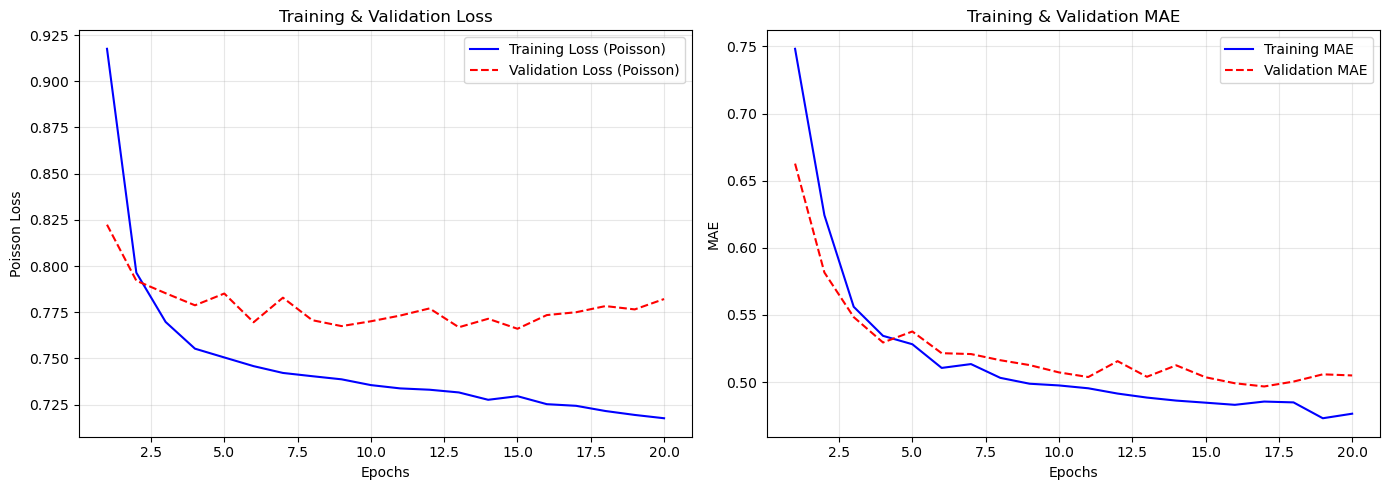

In [14]:
loss_lstm = history_lstm.history['loss']
val_loss_lstm = history_lstm.history['val_loss']
mae_lstm = history_lstm.history['mae']
val_mae_lstm = history_lstm.history['val_mae']
epochs_lstm = range(1, len(loss_lstm) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_lstm, loss_lstm, 'b-', label='Training Loss (Poisson)')
plt.plot(epochs_lstm, val_loss_lstm, 'r--', label='Validation Loss (Poisson)')
plt.xlabel('Epochs')
plt.ylabel('Poisson Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_lstm, mae_lstm, 'b-', label='Training MAE')
plt.plot(epochs_lstm, val_mae_lstm, 'r--', label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Training & Validation MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Gated Recurrent Unit (GRU) Model

In [16]:
model_gru,early_stopping_gru=build_gru(timesteps,num_features)

history_gru = model_gru.fit(
    X_train_scaled,
    y_train,
    sample_weight=mask_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_scaled, y_val, mask_val),
    callbacks=[early_stopping_gru]
)


Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 0.9735 - mae: 0.8153 - val_loss: 0.8872 - val_mae: 0.7009
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.8306 - mae: 0.6379 - val_loss: 0.8125 - val_mae: 0.5794
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.7798 - mae: 0.5536 - val_loss: 0.7811 - val_mae: 0.5358
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.7598 - mae: 0.5275 - val_loss: 0.7830 - val_mae: 0.5241
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.7537 - mae: 0.5251 - val_loss: 0.7780 - val_mae: 0.5319
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.7500 - mae: 0.5197 - val_loss: 0.7668 - val_mae: 0.5286
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.7478 - mae: 0.5184 - val_loss: 0.7738 - val_mae: 0.5204
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.7459 - mae: 0.5189 - val_loss: 0.7693 - val_mae: 0.5189
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.74

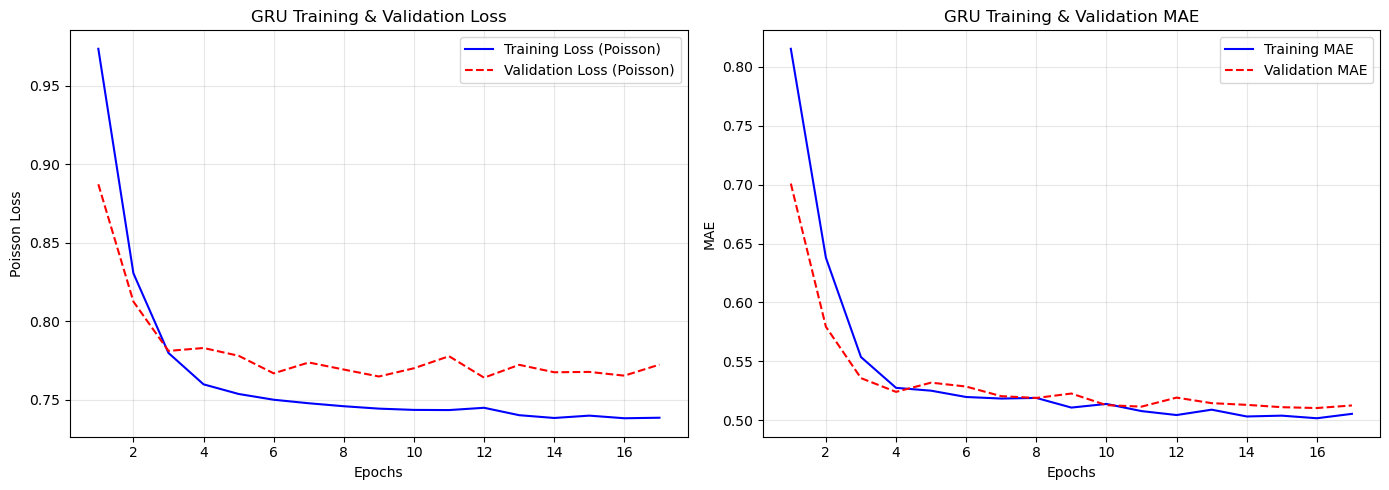

In [17]:
loss_gru = history_gru.history['loss']
val_loss_gru = history_gru.history['val_loss']
mae_gru_hist = history_gru.history['mae']
val_mae_gru_hist = history_gru.history['val_mae']
epochs_gru = range(1, len(loss_gru) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_gru, loss_gru, 'b-', label='Training Loss (Poisson)')
plt.plot(epochs_gru, val_loss_gru, 'r--', label='Validation Loss (Poisson)')
plt.xlabel('Epochs')
plt.ylabel('Poisson Loss')
plt.title('GRU Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_gru, mae_gru_hist, 'b-', label='Training MAE')
plt.plot(epochs_gru, val_mae_gru_hist, 'r--', label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('GRU Training & Validation MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Predictions

In [48]:
# LSTM predictions
y_pred_lstm_3d = model_lstm.predict(X_test_scaled)
real_mask      = mask_test.reshape(-1) == 1
y_pred_goals   = y_pred_lstm_3d.reshape(-1, 2)[real_mask]
y_true_goals   = y_test.reshape(-1, 2)[real_mask]

goal_diff_test  = possession_features[possession_features['match_id'].isin(test_ids)].sort_values(['match_id','possession'])['goal_diff'].values
test_rows       = possession_features[possession_features['match_id'].isin(test_ids)].sort_values(['match_id','possession']).reset_index(drop=True)

home_p, draw_p, away_p = poisson_wdl_from_lambdas(
    test_rows['goal_diff'].values,
    y_pred_goals[:, 0],
    y_pred_goals[:, 1]
)
probs    = np.column_stack([home_p, draw_p, away_p])
outcomes = test_rows['final_outcome'].astype(int).values

mae_goals  = mean_absolute_error(y_true_goals, y_pred_goals)
rps_lstm   = ranked_probability_score(probs, outcomes)
brier_lstm = multiclass_brier_score(probs, outcomes)

print(f"LSTM — MAE: {mae_goals:.6f} | RPS: {rps_lstm:.6f} | Brier: {brier_lstm:.6f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
LSTM — MAE: 0.659319 | RPS: 0.107447 | Brier: 0.358221


In [44]:
# GRU predictions 
y_pred_gru_3d  = model_gru.predict(X_test_scaled)
y_pred_goals_gru = y_pred_gru_3d.reshape(-1, 2)[real_mask]

home_p_gru, draw_p_gru, away_p_gru = poisson_wdl_from_lambdas(
    test_rows['goal_diff'].values,
    y_pred_goals_gru[:, 0],
    y_pred_goals_gru[:, 1]
)
probs_gru    = np.column_stack([home_p_gru, draw_p_gru, away_p_gru])
outcomes_gru = outcomes.copy()

mae_gru    = mean_absolute_error(y_true_goals, y_pred_goals_gru)
rps_gru    = ranked_probability_score(probs_gru, outcomes_gru)
brier_gru  = multiclass_brier_score(probs_gru, outcomes_gru)

print(f"GRU  — MAE: {mae_gru:.6f} | RPS: {rps_gru:.6f} | Brier: {brier_gru:.6f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
GRU  — MAE: 0.655017 | RPS: 0.105966 | Brier: 0.354780


In [46]:
# Baseline metrics 
from sklearn.metrics import mean_absolute_error as mae_fn
baseline_mae   = mae_fn(test_data[target_cols], baseline_goal_pred)
baseline_rps   = ranked_probability_score(baseline_probs, baseline_outcomes)
baseline_brier = multiclass_brier_score(baseline_probs, baseline_outcomes)

print(f"Baseline — MAE: {baseline_mae:.6f} | RPS: {baseline_rps:.6f} | Brier: {baseline_brier:.6f}")

Baseline — MAE: 0.767665 | RPS: 0.137706 | Brier: 0.448831


In [40]:
# Save everything for notebook 04
model_lstm.save('../models/lstm_model.keras')
model_gru.save('../models/gru_model.keras')

results = {
    'probs_lstm'      : probs,
    'probs_gru'       : probs_gru,
    'outcomes'        : outcomes,
    'y_pred_goals'    : y_pred_goals,
    'y_pred_goals_gru': y_pred_goals_gru,
    'y_true_goals'    : y_true_goals,
    'test_rows'       : test_rows,
    'mae_goals'       : mae_goals,
    'mae_gru'         : mae_gru,
    'rps_lstm'        : rps_lstm,
    'rps_gru'         : rps_gru,
    'brier_lstm'      : brier_lstm,
    'brier_gru'       : brier_gru,
    'baseline_mae'    : baseline_mae,
    'baseline_rps'    : baseline_rps,
    'baseline_brier'  : baseline_brier,
    'baseline_probs'  : baseline_probs,
    'baseline_outcomes': baseline_outcomes,
    'history_lstm'    : {
        'loss'    : loss_lstm,
        'val_loss': val_loss_lstm,
        'mae'     : mae_lstm,
        'val_mae' : val_mae_lstm,
    },
    'history_gru'     : {
        'loss'    : loss_gru,
        'val_loss': val_loss_gru,
        'mae'     : mae_gru_hist,
        'val_mae' : val_mae_gru_hist,
    },
}

with open('../results/predictions.pkl', 'wb') as f:
    pickle.dump(results, f)

print("=" * 48)
print("Notebook 03 — all outputs saved")
print("=" * 48)
print(f"  LSTM  — RPS: {rps_lstm:.4f} | Brier: {brier_lstm:.4f}")
print(f"  GRU   — RPS: {rps_gru:.4f} | Brier: {brier_gru:.4f}")
print(f"  Base  — RPS: {baseline_rps:.4f} | Brier: {baseline_brier:.4f}")
print("=" * 48)

Notebook 03 — all outputs saved
  LSTM  — RPS: 0.1074 | Brier: 0.3582
  GRU   — RPS: 0.1060 | Brier: 0.3548
  Base  — RPS: 0.1377 | Brier: 0.4488
